In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
df = pd.read_csv("stanbydiesel.csv") 
df.head()

,month,load(Mw),class
0,4,40,no
1,6,50,no
2,7,80,no
3,10,100,no
4,12,120,no


In [8]:
df = df.drop(columns=["class"])
df.head() 

,month,load(Mw)
0,4,40
1,6,50
2,7,80
3,10,100
4,12,120


In [17]:
import pandas as p
df = pd.read_csv("stanbydiesel.csv")
df.columns = df.columns.str.strip()
K = {'no': 0, 'yes': 1}
df['class'] = df['class'].str.strip().map(K)
X = df[['month', 'load(Mw)']]
y = df['class']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred = clf.predict (X_test) 
y_pred

array([1, 0, 0])

In [19]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score 
print("accuracy score",accuracy_score(y_test, y_pred)) 
print("mean_squared_error",mean_squared_error(y_test, y_pred)) 
from sklearn.metrics import confusion_matrix

accuracy score 1.0
mean_squared_error 0.0


In [20]:
y_true = y_test 
data = confusion_matrix(y_true, y_pred) 
data

array([[2, 0],
       [0, 1]])

In [21]:
import seaborn as sn 
df_cm = pd.DataFrame(data, columns=np.unique(y_true), index =np.unique(y_true)) 
df_cm.index.name = "Actual" 
df_cm.columns.name = "Predicted" 
plt.figure(figsize = (10,7)) 
sn.set(font_scale=1.4) 
df_cm

Predicted,0,1
Actual,,
0,2,0
1,0,1


<Figure size 1000x700 with 0 Axes>

<Axes: xlabel='Predicted', ylabel='Actual'>

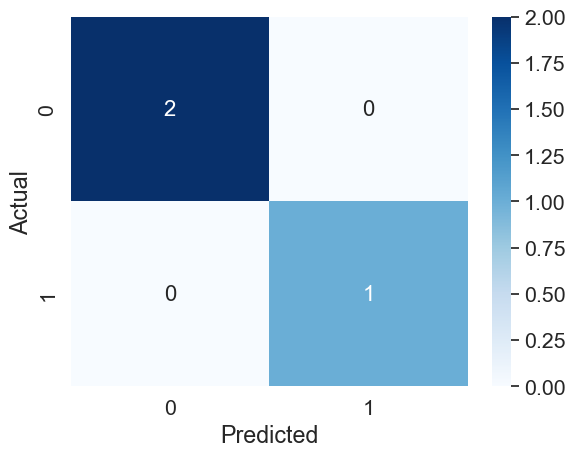

In [22]:
sn.heatmap(df_cm, cmap="Blues", annot=True,annot_kws= {"size":16}) 